# GAI adoption analysis

This notebook contains the three descriptive figures used to examine GAI adoption in take-home exams. It loads the analysis-ready data produced by the cleaning pipeline and does not repeat data-cleaning steps.

### Setup

Define the data and figure paths, shared colors, the post-ChatGPT date, and common time-series formatting. Blue and red are used consistently across all three figures; gray/black are reserved for reference lines.

In [2]:
#!pip install fastparquet scipy

In [3]:
from pathlib import Path
from scipy.stats import gaussian_kde

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.patheffects as pe

# Paths
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data"
OUTPUT_PATH = PROJECT_ROOT / "outputs"

ANALYSIS_DATA_PATH = DATA_PATH / "analysis_data_public.parquet"
PLOT_PATH = OUTPUT_PATH / "figures"

# Create the figure directory if it does not already exist.
PLOT_PATH.mkdir(parents=True, exist_ok=True)


# Analysis date
POST_PERIOD_START = pd.Timestamp("2023-01-01")


# Shared presentation colors
COLORS = {
    "before": "#4C78A8",
    "after": "#E45756",
    "threshold": "#2F2F2F",
    "reference": "#666666",
}


def format_time_axis(ax):
    """Apply consistent styling to time-series axes."""
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.20)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def add_chatgpt_marker(ax):
    """Mark the first post-ChatGPT half-year bin."""
    ax.axvline(
        POST_PERIOD_START,
        color=COLORS["threshold"],
        linestyle=":",
        linewidth=1.4,
    )


### Load analysis data

Load the analysis-ready dataset and report its size and observed date range. The date restrictions themselves belong in the cleaning script rather than this notebook.

In [4]:
analysis_data = pd.read_parquet(ANALYSIS_DATA_PATH)

print(f"Analysis sample: {len(analysis_data):,} hand-ins")

Analysis sample: 44,374 hand-ins


### Prepare the adoption sample

The adoption analysis uses take-home exams only. The adoption threshold is the 99th percentile of `rare_per_100` in the pre-ChatGPT take-home sample and is then held fixed for all periods.

In [5]:

# Split into pre- and post-ChatGPT periods
pre_analysis_data = analysis_data.loc[
    analysis_data["after"] == 0
].copy()

post_analysis_data = analysis_data.loc[
    analysis_data["after"] == 1
].copy()

# Define the fixed adoption threshold from the pre-ChatGPT distribution
PRE_P99 = pre_analysis_data["rare_per_100"].quantile(0.99)

# Indicator for observations above the fixed pre-period threshold
analysis_data["above_pre_p99"] = (
    analysis_data["rare_per_100"] > PRE_P99
).astype(int)

print(f"Take-home hand-ins: {len(analysis_data):,}")
print(f"Pre-ChatGPT: {len(pre_analysis_data):,}")
print(f"Post-ChatGPT: {len(post_analysis_data):,}")
print(f"Pre-ChatGPT p99 threshold: {PRE_P99:.4f}")

analysis_data.groupby("after")["rare_per_100"].describe()


Take-home hand-ins: 44,374
Pre-ChatGPT: 32,911
Post-ChatGPT: 11,463
Pre-ChatGPT p99 threshold: 1.1203


,count,mean,std,min,25%,50%,75%,max
after,,,,,,,,
0.0,32911.0,0.317775,0.244004,0.0,0.151573,0.271739,0.427235,3.415941
1.0,11463.0,0.507241,0.506862,0.0,0.205467,0.372077,0.621918,6.527909


### Rare LLM-word use over time

The figure shows the mean number of rare LLM words per 100 words among take-home hand-ins in each half-year. The dotted vertical line marks the beginning of the post-ChatGPT period.

In [6]:
# ================================================================
# RARE LLM WORDS OVER TIME WITH COURSE-CLUSTER BOOTSTRAP 95% CI
# ================================================================

N_BOOT = 1000
BOOTSTRAP_SEED = 42
CLUSTER_COL = "coursecode_clean"


# ------------------------------------------------
# Observed half-year means
# ------------------------------------------------

rare_time = (
    analysis_data
    .groupby(
        ["period_start", "period"],
        as_index=False,
    )
    .agg(
        rare_mean=("rare_per_100", "mean"),
        handins=("rare_per_100", "count"),
    )
    .sort_values("period_start")
)


# ------------------------------------------------
# Course × period statistics for bootstrap
# ------------------------------------------------

course_period = (
    analysis_data
    .dropna(
        subset=[
            CLUSTER_COL,
            "period_start",
            "rare_per_100",
        ]
    )
    .groupby(
        [CLUSTER_COL, "period_start"],
        as_index=False,
    )
    .agg(
        rare_sum=("rare_per_100", "sum"),
        rare_count=("rare_per_100", "count"),
    )
)

cluster_ids = course_period[CLUSTER_COL].unique()
periods = rare_time["period_start"].to_numpy()

In [7]:
# ------------------------------------------------
# Course-cluster bootstrap
# ------------------------------------------------

rng = np.random.default_rng(BOOTSTRAP_SEED)

bootstrap_means = np.full(
    (N_BOOT, len(periods)),
    np.nan,
)

for b in tqdm(range(N_BOOT), desc="Bootstrap"):

    sampled_clusters = rng.choice(
        cluster_ids,
        size=len(cluster_ids),
        replace=True,
    )

    bootstrap_weights = (
        pd.Series(sampled_clusters)
        .value_counts()
        .rename("bootstrap_weight")
    )

    boot = course_period.merge(
        bootstrap_weights,
        left_on=CLUSTER_COL,
        right_index=True,
        how="inner",
        validate="many_to_one",
    )

    boot["weighted_sum"] = (
        boot["rare_sum"] * boot["bootstrap_weight"]
    )

    boot["weighted_count"] = (
        boot["rare_count"] * boot["bootstrap_weight"]
    )

    boot_period = (
        boot
        .groupby("period_start")
        .agg(
            weighted_sum=("weighted_sum", "sum"),
            weighted_count=("weighted_count", "sum"),
        )
    )

    boot_period["rare_mean"] = (
        boot_period["weighted_sum"]
        / boot_period["weighted_count"]
    )

    bootstrap_means[b, :] = (
        boot_period["rare_mean"]
        .reindex(periods)
        .to_numpy()
    )

Bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

In [8]:
# ------------------------------------------------
# 95% bootstrap confidence intervals
# ------------------------------------------------

rare_time["ci_low"] = np.nanpercentile(
    bootstrap_means,
    2.5,
    axis=0,
)

rare_time["ci_high"] = np.nanpercentile(
    bootstrap_means,
    97.5,
    axis=0,
)

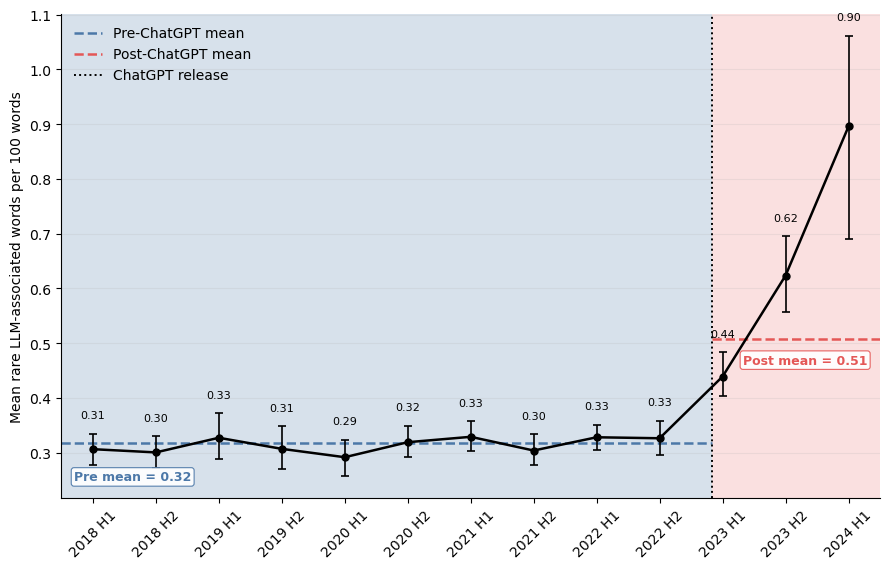

In [9]:
# ------------------------------------------------
# Plot
# ------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5.8))

CHATGPT_RELEASE = pd.Timestamp("2022-11-30")


# ------------------------------------------------
# Numeric positions for half-year periods
# ------------------------------------------------

x = np.arange(len(rare_time))

period_dates = pd.to_datetime(
    rare_time["period_start"]
)

chatgpt_x = np.interp(
    CHATGPT_RELEASE.value,
    period_dates.astype("int64"),
    x,
)


# ------------------------------------------------
# Before / after background shading
# ------------------------------------------------

ax.axvspan(
    -0.5,
    chatgpt_x,
    facecolor=COLORS["before"],
    alpha=0.22,
    zorder=0,
)

ax.axvspan(
    chatgpt_x,
    len(rare_time) - 0.5,
    facecolor=COLORS["after"],
    alpha=0.18,
    zorder=0,
)


# ------------------------------------------------
# Convert confidence interval bounds
# to asymmetric whisker lengths
# ------------------------------------------------

yerr = np.vstack([
    rare_time["rare_mean"] - rare_time["ci_low"],
    rare_time["ci_high"] - rare_time["rare_mean"],
])


# ------------------------------------------------
# Mean line and 95% CI whiskers
# ------------------------------------------------

ax.errorbar(
    x,
    rare_time["rare_mean"],
    yerr=yerr,
    fmt="o-",
    color="black",
    ecolor="black",
    linewidth=1.8,
    markersize=5,
    elinewidth=1.2,
    capsize=3,
    capthick=1.2,
    zorder=3,
)


# ------------------------------------------------
# Point-value annotations
# ------------------------------------------------

for position, row in rare_time.reset_index(drop=True).iterrows():

    ax.text(
        position,
        row["ci_high"] + 0.025,
        f"{row['rare_mean']:.2f}",
        ha="center",
        va="bottom",
        fontsize=8,
        color="black",
        zorder=4,
    )


# ------------------------------------------------
# Pooled pre- and post-ChatGPT means
# ------------------------------------------------

pre_mean = analysis_data.loc[
    analysis_data["after"] == 0,
    "rare_per_100",
].mean()

post_mean = analysis_data.loc[
    analysis_data["after"] == 1,
    "rare_per_100",
].mean()


# ------------------------------------------------
# Horizontal pooled-mean lines
# ------------------------------------------------

ax.hlines(
    pre_mean,
    xmin=-0.5,
    xmax=chatgpt_x,
    color=COLORS["before"],
    linestyle="--",
    linewidth=1.8,
    label="Pre-ChatGPT mean",
    zorder=2,
)

ax.hlines(
    post_mean,
    xmin=chatgpt_x,
    xmax=len(rare_time) - 0.5,
    color=COLORS["after"],
    linestyle="--",
    linewidth=1.8,
    label="Post-ChatGPT mean",
    zorder=2,
)


# ------------------------------------------------
# Mean annotations
# ------------------------------------------------

ax.text(
    -0.30,
    pre_mean - 0.05,
    f"Pre mean = {pre_mean:.2f}",
    color=COLORS["before"],
    ha="left",
    va="top",
    fontsize=9,
    fontweight="bold",
    bbox={
        "boxstyle": "round,pad=0.22",
        "facecolor": "white",
        "edgecolor": COLORS["before"],
        "linewidth": 0.8,
        "alpha": 0.92,
    },
    zorder=5,
)

ax.text(
    len(rare_time) - 0.70,
    post_mean - 0.05,
    f"Post mean = {post_mean:.2f}",
    color=COLORS["after"],
    ha="right",
    va="bottom",
    fontsize=9,
    fontweight="bold",
    bbox={
        "boxstyle": "round,pad=0.22",
        "facecolor": "white",
        "edgecolor": COLORS["after"],
        "linewidth": 0.8,
        "alpha": 0.92,
    },
    zorder=5,
)


# ------------------------------------------------
# ChatGPT release marker
# ------------------------------------------------

ax.axvline(
    chatgpt_x,
    color="black",
    linestyle=":",
    linewidth=1.4,
    label="ChatGPT release",
    zorder=2,
)


# ------------------------------------------------
# X-axis: half-year labels
# ------------------------------------------------

ax.set_xticks(x)

ax.set_xticklabels(
    rare_time["period"],
    rotation=45,
)

ax.set_xlim(
    -0.5,
    len(rare_time) - 0.5,
)


# ------------------------------------------------
# Labels and styling
# ------------------------------------------------

ax.set_ylabel(
    "Mean rare LLM-associated words per 100 words"
)

format_time_axis(ax)

ax.legend(
    frameon=False,
    loc="upper left",
)


# ------------------------------------------------
# Final layout and save
# ------------------------------------------------

plt.tight_layout()

fig.savefig(
    PLOT_PATH / "gai_adoption_mean_rare_words.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    PLOT_PATH / "gai_adoption_mean_rare_words.svg",
    bbox_inches="tight",
)

plt.show()

In [10]:
# ================================================================
# EXACT PRE- / POST-CHATGPT MEAN RARE-WORD CHANGE
# ================================================================

pre_mean = (
    analysis_data.loc[
        analysis_data["after"] == 0,
        "rare_per_100",
    ]
    .dropna()
    .mean()
)

post_mean = (
    analysis_data.loc[
        analysis_data["after"] == 1,
        "rare_per_100",
    ]
    .dropna()
    .mean()
)

absolute_change = (
    post_mean - pre_mean
)

percent_change = (
    absolute_change
    / pre_mean
    * 100
)

ratio = (
    post_mean
    / pre_mean
)


print(
    f"Pre-ChatGPT mean:  {pre_mean:.4f}"
)

print(
    f"Post-ChatGPT mean: {post_mean:.4f}"
)

print(
    f"Absolute change:   {absolute_change:.4f}"
)

print(
    f"Percent change:    {percent_change:.1f}%"
)

print(
    f"Post / pre ratio:  {ratio:.2f}x"
)

Pre-ChatGPT mean:  0.3178
Post-ChatGPT mean: 0.5072
Absolute change:   0.1895
Percent change:    59.6%
Post / pre ratio:  1.60x


In [11]:
# ================================================================
# INDIVIDUAL RARE LLM WORDS: PRE- VS. POST-CHATGPT
# ================================================================

# Individual rare-word measures are already included in the
# final analytical dataset produced by 7_3.
word_analysis = analysis_data.copy()

required_word_cols = [
    "rare_freqs",
    "llm_n_words",
]

missing_word_cols = [
    col
    for col in required_word_cols
    if col not in word_analysis.columns
]

if missing_word_cols:
    raise KeyError(
        "Final analysis dataset is missing required individual "
        f"LLM-word variables: {missing_word_cols}"
    )

In [12]:
# ================================================================
# WORD-LEVEL PRE / POST RATES
# ================================================================

# Total number of words in each period.
period_word_totals = (
    word_analysis
    .groupby("after")["llm_n_words"]
    .sum()
)

pre_total_words = period_word_totals.loc[0]
post_total_words = period_word_totals.loc[1]


# ------------------------------------------------
# Expand rare_freqs dictionaries to long format
# ------------------------------------------------

word_records = []

for row in word_analysis[
    ["after", "rare_freqs"]
].itertuples(index=False):

    # Submissions with no matched rare words may have an empty dict.
    if not isinstance(row.rare_freqs, dict):
        continue

    for word, count in row.rare_freqs.items():
        word_records.append(
            {
                "after": row.after,
                "word": word,
                "count": count,
            }
        )

word_long = pd.DataFrame(word_records)


# ------------------------------------------------
# Sum occurrences by word and period
# ------------------------------------------------

word_counts = (
    word_long
    .groupby(
        ["word", "after"],
        as_index=False,
    )["count"]
    .sum()
)


# Wide format: one row per word
word_summary = (
    word_counts
    .pivot(
        index="word",
        columns="after",
        values="count",
    )
    .fillna(0)
    .rename(
        columns={
            0: "pre_count",
            1: "post_count",
        }
    )
    .reset_index()
)


# Ensure both columns exist even if a word occurs
# exclusively in one of the two periods.
for col in ["pre_count", "post_count"]:
    if col not in word_summary.columns:
        word_summary[col] = 0


# ------------------------------------------------
# Convert counts to occurrences per 100 words
# ------------------------------------------------

word_summary["pre_rate"] = (
    word_summary["pre_count"]
    / pre_total_words
    * 100
)

word_summary["post_rate"] = (
    word_summary["post_count"]
    / post_total_words
    * 100
)

word_summary["delta"] = (
    word_summary["post_rate"]
    - word_summary["pre_rate"]
)


# Useful diagnostics
print(
    f"Pre words:  {pre_total_words:,.0f}"
)

print(
    f"Post words: {post_total_words:,.0f}"
)

display(
    word_summary
    .sort_values(
        "post_rate",
        ascending=False,
    )
    .head(20)
)

Pre words:  161,642,862
Post words: 53,431,126


after,word,pre_count,post_count,pre_rate,post_rate,delta
163,integration,24209,10373,0.014977,0.019414,0.004437
172,involves,10609,6607,0.006563,0.012365,0.005802
30,broader,11892,6275,0.007357,0.011744,0.004387
44,consequently,16200,5855,0.010022,0.010958,0.000936
267,ultimately,13172,5426,0.008149,0.010155,0.002006
143,hold,13803,5199,0.008539,0.009730,0.001191
84,emphasizes,6766,4692,0.004186,0.008781,0.004596
266,typically,9924,4537,0.006139,0.008491,0.002352
236,shaping,6079,4514,0.003761,0.008448,0.004687
102,ensuring,8044,4441,0.004976,0.008312,0.003335


In [13]:
# The sum across individual-word rates should reproduce
# the pooled rare-word rate in each period.

print(
    "Sum of pre individual-word rates:",
    word_summary["pre_rate"].sum(),
)

print(
    "Observed pooled pre rare_per_100:",
    analysis_data.loc[
        analysis_data["after"] == 0,
        "rare_per_100",
    ].mean(),
)

print(
    "Sum of post individual-word rates:",
    word_summary["post_rate"].sum(),
)

print(
    "Observed pooled post rare_per_100:",
    analysis_data.loc[
        analysis_data["after"] == 1,
        "rare_per_100",
    ].mean(),
)

Sum of pre individual-word rates: 0.3257972504842187
Observed pooled pre rare_per_100: 0.3177745701026591
Sum of post individual-word rates: 0.5112488177771136
Observed pooled post rare_per_100: 0.5072413018165127


In [14]:
# ================================================================
# TWO TOP-10 DEFINITIONS
# ================================================================

# A. Most prevalent rare words in the post-ChatGPT period
top10_post = (
    word_summary
    .sort_values(
        "post_rate",
        ascending=False,
    )
    .head(10)
    .copy()
)

# B. Rare words with the largest absolute increase
top10_delta = (
    word_summary
    .sort_values(
        "delta",
        ascending=False,
    )
    .head(10)
    .copy()
)


print("Top 10 by post-ChatGPT rate")
display(
    top10_post[
        [
            "word",
            "pre_rate",
            "post_rate",
            "delta",
            "pre_count",
            "post_count",
        ]
    ]
)

print("Top 10 by pre-post difference")
display(
    top10_delta[
        [
            "word",
            "pre_rate",
            "post_rate",
            "delta",
            "pre_count",
            "post_count",
        ]
    ]
)

Top 10 by post-ChatGPT rate


after,word,pre_rate,post_rate,delta,pre_count,post_count
163,integration,0.014977,0.019414,0.004437,24209,10373
172,involves,0.006563,0.012365,0.005802,10609,6607
30,broader,0.007357,0.011744,0.004387,11892,6275
44,consequently,0.010022,0.010958,0.000936,16200,5855
267,ultimately,0.008149,0.010155,0.002006,13172,5426
143,hold,0.008539,0.009730,0.001191,13803,5199
84,emphasizes,0.004186,0.008781,0.004596,6766,4692
266,typically,0.006139,0.008491,0.002352,9924,4537
236,shaping,0.003761,0.008448,0.004687,6079,4514
102,ensuring,0.004976,0.008312,0.003335,8044,4441


Top 10 by pre-post difference


after,word,pre_rate,post_rate,delta,pre_count,post_count
172,involves,0.006563,0.012365,0.005802,10609,6607
236,shaping,0.003761,0.008448,0.004687,6079,4514
84,emphasizes,0.004186,0.008781,0.004596,6766,4692
163,integration,0.014977,0.019414,0.004437,24209,10373
30,broader,0.007357,0.011744,0.004387,11892,6275
18,aligns,0.001093,0.004653,0.003560,1767,2486
102,ensuring,0.004976,0.008312,0.003335,8044,4441
234,serves,0.004790,0.008081,0.003292,7742,4318
118,exploration,0.002591,0.005871,0.003280,4188,3137
16,align,0.002099,0.005313,0.003214,3393,2839


In [15]:
def plot_word_dumbbell(
    data,
    title,
    output_name,
    annotate_pct=True,
):

    plot_data = (
        data
        .sort_values(
            "post_rate",
            ascending=True,
        )
        .reset_index(drop=True)
    )

    y = np.arange(len(plot_data))

    fig, ax = plt.subplots(figsize=(7.5, 5.8))

    # Connecting lines
    for i, row in plot_data.iterrows():
        x0 = row["pre_rate"]
        x1 = row["post_rate"]

        ax.plot(
            [x0, x1],
            [i, i],
            color="#B0B0B0",
            linewidth=1.5,
            zorder=1,
        )

        if annotate_pct:
            # Percentage increase relative to pre-period rate
            if pd.notnull(x0) and x0 > 0:
                pct_change = ((x1 - x0) / x0) * 100
                label = f"{pct_change:+.0f}%"
            else:
                label = "new"

            x_mid = (x0 + x1) / 2

            ax.text(
                x_mid,
                i + 0.18,
                label,
                ha="center",
                va="bottom",
                fontsize=8,
                color="#4D4D4D",
            )

    # Pre-period values
    ax.scatter(
        plot_data["pre_rate"],
        y,
        s=55,
        color=COLORS["before"],
        label="Pre-ChatGPT",
        zorder=3,
    )

    # Post-period values
    ax.scatter(
        plot_data["post_rate"],
        y,
        s=55,
        color=COLORS["after"],
        label="Post-ChatGPT",
        zorder=3,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(plot_data["word"])

    ax.set_xlabel("Occurrences per 100 words")
    ax.set_ylabel("")

    ax.set_title(title, loc="left")

    ax.grid(axis="x", alpha=0.20)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.legend(
        frameon=False,
        loc="lower right",
    )

    fig.tight_layout()

    fig.savefig(
        PLOT_PATH / output_name,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

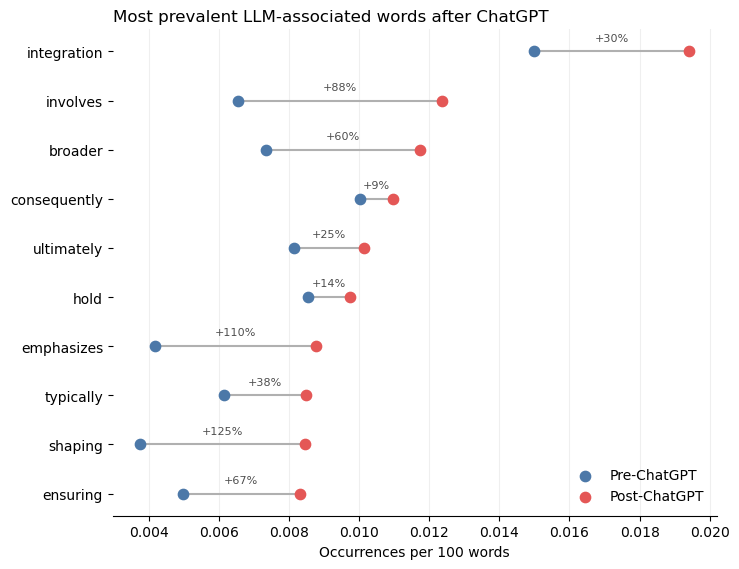

In [16]:
plot_word_dumbbell(
    top10_post,
    title="Most prevalent LLM-associated words after ChatGPT",
    output_name="gai_adoption_top10_post_dumbbell.png",
)

### Distribution of rare LLM-word use

The histogram compares the distribution of rare LLM-word use in take-home exams before and after ChatGPT. The dashed vertical line marks the 99th percentile of the pre-ChatGPT distribution.

Pre-period p99 threshold: 1.1203
Pre KDE mass:  1.000000
Post KDE mass: 1.000000
Shared mass:   0.8021
Excess mass:   0.1979
Deficit mass:  0.1979
Difference:    0.00000000
Estimated shifted probability mass: 19.8%


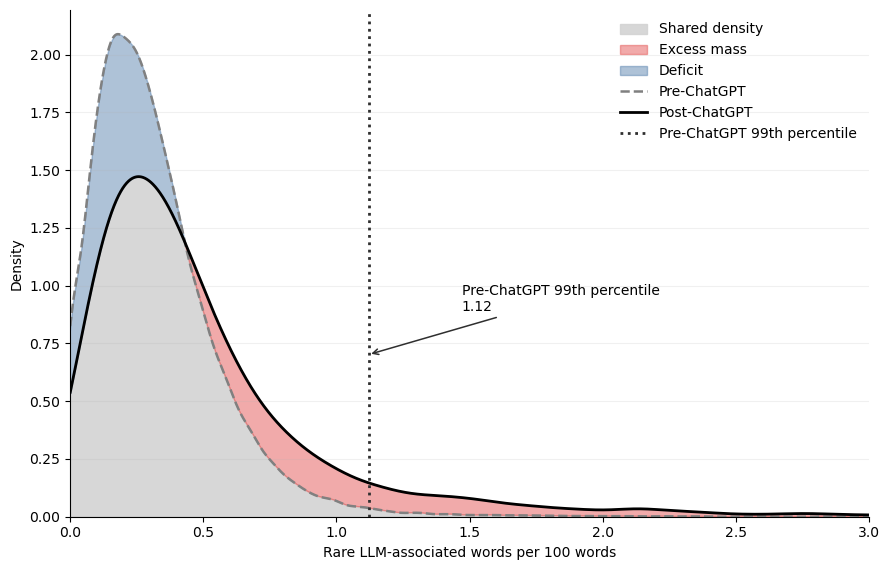

In [17]:
# ================================================================
# KDE EXCESS-MASS DECOMPOSITION:
# PRE-CHATGPT VS. POST-CHATGPT
# ================================================================
# ------------------------------------------------
# 1. Prepare observed distributions
# ------------------------------------------------

pre_values = (
    analysis_data
    .loc[
        analysis_data["after"] == 0,
        "rare_per_100",
    ]
    .dropna()
    .to_numpy()
)

post_values = (
    analysis_data
    .loc[
        analysis_data["after"] == 1,
        "rare_per_100",
    ]
    .dropna()
    .to_numpy()
)


# ------------------------------------------------
# 2. Pre-period p99 threshold
# ------------------------------------------------

PRE_P99 = np.quantile(
    pre_values,
    0.99,
)


# ------------------------------------------------
# 3. Estimate KDEs
# ------------------------------------------------

pre_kde = gaussian_kde(
    pre_values,
    bw_method="scott",
)

post_kde = gaussian_kde(
    post_values,
    bw_method="scott",
)


# ------------------------------------------------
# 4. Common integration grid
# ------------------------------------------------
#
# Gaussian KDEs have support beyond the observed data,
# including slightly below zero. We therefore construct
# a common grid wide enough to capture essentially all
# probability mass from both estimated densities.
#
# The plotting range can still be restricted later.

combined_values = np.concatenate([
    pre_values,
    post_values,
])

pre_bandwidth = np.sqrt(
    pre_kde.covariance[0, 0]
)

post_bandwidth = np.sqrt(
    post_kde.covariance[0, 0]
)

max_bandwidth = max(
    pre_bandwidth,
    post_bandwidth,
)

x_min = (
    combined_values.min()
    - 6 * max_bandwidth
)

x_max = (
    combined_values.max()
    + 6 * max_bandwidth
)

x_grid = np.linspace(
    x_min,
    x_max,
    5000,
)


# ------------------------------------------------
# 5. Evaluate and normalize KDEs
# ------------------------------------------------

pre_density = pre_kde(
    x_grid
)

post_density = post_kde(
    x_grid
)

pre_mass_raw = np.trapezoid(
    pre_density,
    x_grid,
)

post_mass_raw = np.trapezoid(
    post_density,
    x_grid,
)

pre_density = (
    pre_density
    / pre_mass_raw
)

post_density = (
    post_density
    / post_mass_raw
)


# ------------------------------------------------
# 6. Excess-mass decomposition
# ------------------------------------------------

shared_density = np.minimum(
    pre_density,
    post_density,
)

excess_density = np.maximum(
    post_density - pre_density,
    0,
)

deficit_density = np.maximum(
    pre_density - post_density,
    0,
)


# ------------------------------------------------
# 7. Integrate probability mass
# ------------------------------------------------

pre_mass = np.trapezoid(
    pre_density,
    x_grid,
)

post_mass = np.trapezoid(
    post_density,
    x_grid,
)

shared_mass = np.trapezoid(
    shared_density,
    x_grid,
)

excess_mass = np.trapezoid(
    excess_density,
    x_grid,
)

deficit_mass = np.trapezoid(
    deficit_density,
    x_grid,
)

estimated_shift_percent = (
    excess_mass * 100
)


# ------------------------------------------------
# 8. Diagnostics
# ------------------------------------------------

print(
    f"Pre-period p99 threshold: {PRE_P99:.4f}"
)

print(
    f"Pre KDE mass:  {pre_mass:.6f}"
)

print(
    f"Post KDE mass: {post_mass:.6f}"
)

print(
    f"Shared mass:   {shared_mass:.4f}"
)

print(
    f"Excess mass:   {excess_mass:.4f}"
)

print(
    f"Deficit mass:  {deficit_mass:.4f}"
)

print(
    f"Difference:    "
    f"{excess_mass - deficit_mass:.8f}"
)

print(
    f"Estimated shifted probability mass: "
    f"{estimated_shift_percent:.1f}%"
)

# ------------------------------------------------
# 7. Plot
# ------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 5.8)
)

# Shared density
ax.fill_between(
    x_grid,
    0,
    shared_density,
    color="lightgray",
    alpha=0.9,
    label="Shared density",
)

# Excess mass: post > pre
ax.fill_between(
    x_grid,
    pre_density,
    post_density,
    where=(post_density > pre_density),
    interpolate=True,
    color=COLORS["after"],
    alpha=0.50,
    label="Excess mass",
)

# Deficit: pre > post
ax.fill_between(
    x_grid,
    post_density,
    pre_density,
    where=(pre_density > post_density),
    interpolate=True,
    color=COLORS["before"],
    alpha=0.45,
    label="Deficit",
)

# Pre-ChatGPT KDE
ax.plot(
    x_grid,
    pre_density,
    color="gray",
    linestyle="--",
    linewidth=1.8,
    label="Pre-ChatGPT",
)

# Post-ChatGPT KDE
ax.plot(
    x_grid,
    post_density,
    color="black",
    linewidth=2.0,
    label="Post-ChatGPT",
)

# Pre-period p99 threshold
ax.axvline(
    PRE_P99,
    color=COLORS["threshold"],
    linestyle=":",
    linewidth=2.0,
    label="Pre-ChatGPT 99th percentile",
)
# Annotate the p99 line
ymax = ax.get_ylim()[1]

ax.annotate(
    f"Pre-ChatGPT 99th percentile\n{PRE_P99:.2f}",
    xy=(
        PRE_P99,
        ymax * 0.32,
    ),
    xytext=(
        PRE_P99 + 0.35,
        ymax * 0.43,
    ),
    arrowprops={
        "arrowstyle": "->",
        "linewidth": 1.1,
        "color": COLORS["threshold"],
    },
    ha="left",
    va="center",
    fontsize=10,
)


# ------------------------------------------------
# 8. Labels
# ------------------------------------------------

#ax.set_title(
#    f"KDE Excess-Mass Decomposition\n"
#    f"{estimated_shift_percent:.1f}% estimated shifted probability mass",
#    fontsize=14,
#    fontweight="bold",
#    pad=12,
#)

ax.set_xlabel(
    "Rare LLM-associated words per 100 words"
)

ax.set_ylabel(
    "Density"
)

ax.legend(
    frameon=False,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.18,
)

plt.xlim(0,3)
plt.ylim(0,ymax)
plt.tight_layout()

fig.savefig(
    PLOT_PATH / "gai_adoption_histogram.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    PLOT_PATH / "gai_adoption_histogram.svg",
    bbox_inches="tight",
)

plt.show()

### Excess above the pre-ChatGPT baseline

The figure shows the percentage-point excess of take-home hand-ins above the fixed pre-ChatGPT p99 threshold relative to its 1% baseline. Each bar is annotated with the corresponding percentage-point difference.

In [18]:
# ================================================================
# EXCESS ABOVE PRE-PERIOD P99 WITH COURSE-CLUSTER BOOTSTRAP 95% CI
# ================================================================
N_BOOT = 1000
BOOTSTRAP_SEED = 42
CLUSTER_COL = "coursecode_clean"


# Indicator for exceeding the observed pre-period p99
above_pre_p99 = (
    analysis_data["rare_per_100"] > PRE_P99
).astype(int)


# Observed period-level uptake
uptake_table = (
    analysis_data
    .assign(above_pre_p99=above_pre_p99)
    .groupby(
        ["period_start", "period"],
        as_index=False,
    )
    .agg(
        Handins=("above_pre_p99", "count"),
        Above_threshold=("above_pre_p99", "sum"),
        Uptake_rate=("above_pre_p99", "mean"),
    )
    .sort_values("period_start")
    .reset_index(drop=True)
)

uptake_table["Uptake_percent"] = (
    uptake_table["Uptake_rate"] * 100
)

# Excess relative to the 1% implied by the p99 threshold
uptake_table["Excess_percentage_points"] = (
    uptake_table["Uptake_percent"] - 1
)


print(f"Observed pre-period p99: {PRE_P99:.4f}")

Observed pre-period p99: 1.1203


In [19]:
# ------------------------------------------------
# 2. Prepare arrays for the course-cluster bootstrap
# ------------------------------------------------

cluster_ids = analysis_data[CLUSTER_COL].unique()

cluster_lookup = {
    cluster: i
    for i, cluster in enumerate(cluster_ids)
}

cluster_codes = (
    analysis_data[CLUSTER_COL]
    .map(cluster_lookup)
    .to_numpy()
)

rare_values = (
    analysis_data["rare_per_100"]
    .to_numpy()
)

after_values = (
    analysis_data["after"]
    .to_numpy()
)

periods = (
    uptake_table["period_start"]
    .to_numpy()
)

period_lookup = {
    period: i
    for i, period in enumerate(periods)
}

period_codes = (
    analysis_data["period_start"]
    .map(period_lookup)
    .to_numpy()
)

In [20]:
# ------------------------------------------------
# 3. Course-cluster bootstrap
# ------------------------------------------------

rng = np.random.default_rng(
    BOOTSTRAP_SEED
)

n_clusters = len(cluster_ids)
n_periods = len(periods)

bootstrap_excess = np.full(
    (N_BOOT, n_periods),
    np.nan,
)

In [21]:
for b in tqdm(
    range(N_BOOT),
    desc="Bootstrap excess",
):

    # --------------------------------------------
    # Resample courses with replacement
    # --------------------------------------------

    sampled_clusters = rng.choice(
        n_clusters,
        size=n_clusters,
        replace=True,
    )

    # Number of times each course is represented
    # in this bootstrap sample
    cluster_weights = np.bincount(
        sampled_clusters,
        minlength=n_clusters,
    )

    # Every hand-in inherits the weight of its course
    row_weights = cluster_weights[
        cluster_codes
    ]


    # --------------------------------------------
    # Re-estimate the pre-period p99
    # --------------------------------------------

    pre_mask = (
        (after_values == 0)
        & (row_weights > 0)
    )

    # Reproduce observations according to how many
    # times their course was sampled
    bootstrap_pre_values = np.repeat(
        rare_values[pre_mask],
        row_weights[pre_mask],
    )

    bootstrap_p99 = np.quantile(
        bootstrap_pre_values,
        0.99,
    )


    # --------------------------------------------
    # Reclassify hand-ins using bootstrap p99
    # --------------------------------------------

    above_threshold = (
        rare_values > bootstrap_p99
    )


    # --------------------------------------------
    # Calculate excess for each half-year
    # --------------------------------------------

    for period_i in range(n_periods):

        period_mask = (
            (period_codes == period_i)
            & (row_weights > 0)
        )

        weights = row_weights[
            period_mask
        ]

        if weights.sum() == 0:
            continue

        bootstrap_uptake = np.average(
            above_threshold[period_mask],
            weights=weights,
        )

        bootstrap_excess[
            b,
            period_i,
        ] = (
            bootstrap_uptake * 100
            - 1
        )

Bootstrap excess:   0%|          | 0/1000 [00:00<?, ?it/s]

In [22]:
# ------------------------------------------------
# 4. 95% bootstrap confidence intervals
# ------------------------------------------------

uptake_table["ci_low"] = np.nanpercentile(
    bootstrap_excess,
    2.5,
    axis=0,
)

uptake_table["ci_high"] = np.nanpercentile(
    bootstrap_excess,
    97.5,
    axis=0,
)

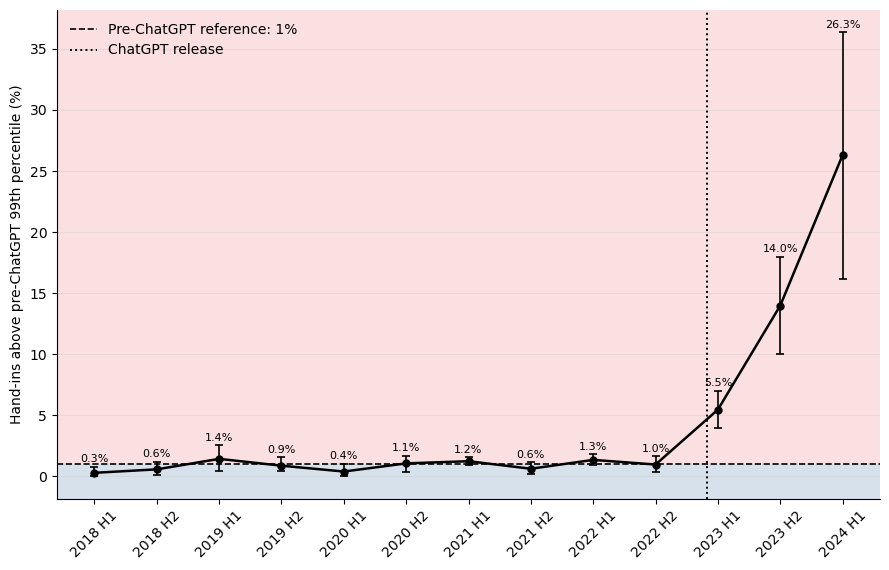

In [23]:
# ------------------------------------------------
# Plot raw uptake percentage with baseline regions
# ------------------------------------------------

# Convert bootstrap excess CIs back to raw percentages
uptake_table["ci_low_percent"] = uptake_table["ci_low"] + 1
uptake_table["ci_high_percent"] = uptake_table["ci_high"] + 1

x = np.arange(len(uptake_table))

y = uptake_table["Uptake_percent"].to_numpy()
ci_low = uptake_table["ci_low_percent"].to_numpy()
ci_high = uptake_table["ci_high_percent"].to_numpy()

baseline = 1.0


fig, ax = plt.subplots(figsize=(9, 5.8))


# ------------------------------------------------
# Main line and 95% CI whiskers
# ------------------------------------------------

yerr = np.vstack([
    y - ci_low,
    ci_high - y,
])

ax.errorbar(
    x,
    y,
    yerr=yerr,
    fmt="o-",
    color="black",
    ecolor="black",
    linewidth=1.8,
    markersize=5,
    elinewidth=1.2,
    capsize=3,
    capthick=1.2,
    zorder=3,
)


# ------------------------------------------------
# Set y-axis limits
# ------------------------------------------------

ymin, ymax = ax.get_ylim()

ymax = max(
    ymax,
    ci_high.max() + 0.5,
)

ax.set_ylim(ymin, ymax)


# ------------------------------------------------
# Shade regions below and above the 1% baseline
# ------------------------------------------------

# Below baseline: blue
ax.axhspan(
    ymin,
    baseline,
    facecolor=COLORS["before"],
    alpha=0.22,
    zorder=0,
)

# Above baseline: red
ax.axhspan(
    baseline,
    ymax,
    facecolor=COLORS["after"],
    alpha=0.18,
    zorder=0,
)


# ------------------------------------------------
# 1% pre-period baseline
# ------------------------------------------------

ax.axhline(
    baseline,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Pre-ChatGPT reference: 1%",
    zorder=2,
)


# ------------------------------------------------
# ChatGPT release marker
# ------------------------------------------------

CHATGPT_RELEASE = pd.Timestamp("2022-11-30")

period_dates = pd.to_datetime(
    uptake_table["period_start"]
)

chatgpt_x = np.interp(
    CHATGPT_RELEASE.value,
    period_dates.astype("int64"),
    x,
)

ax.axvline(
    chatgpt_x,
    color="black",
    linestyle=":",
    linewidth=1.4,
    label="ChatGPT release",
    zorder=2,
)

# ------------------------------------------------
# X-axis
# ------------------------------------------------

ax.set_xticks(x)

ax.set_xticklabels(
    uptake_table["period"],
    rotation=45,
)


# ------------------------------------------------
# Labels
# ------------------------------------------------

#ax.set_title(
#    "Share above the pre-period p99",
#    fontsize=14,
#    fontweight="bold",
#    pad=12,
#)

ax.set_ylabel(
    "Hand-ins above pre-ChatGPT 99th percentile (%)"
)

format_time_axis(ax)


# ------------------------------------------------
# Value annotations
# ------------------------------------------------

for position, row in uptake_table.iterrows():

    ax.text(
        position,
        row["ci_high_percent"] + 0.20,
        f"{row['Uptake_percent']:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        color="black",
        zorder=4,
    )


# Baseline legend
ax.legend(
    frameon=False,
    loc="upper left",
)


plt.tight_layout()

fig.savefig(
    PLOT_PATH / "gai_adoption_share_above_p99.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    PLOT_PATH / "gai_adoption_share_above_p99.svg",
    bbox_inches="tight",
)

plt.show()

## Combined Figure 1 for PNAS Nexus

Creates the four-panel adoption figure as a single 2×2 figure file. Panels are labeled A–D in the upper-left corner and the final figure is saved as vector PDF plus a 600 dpi PNG preview.


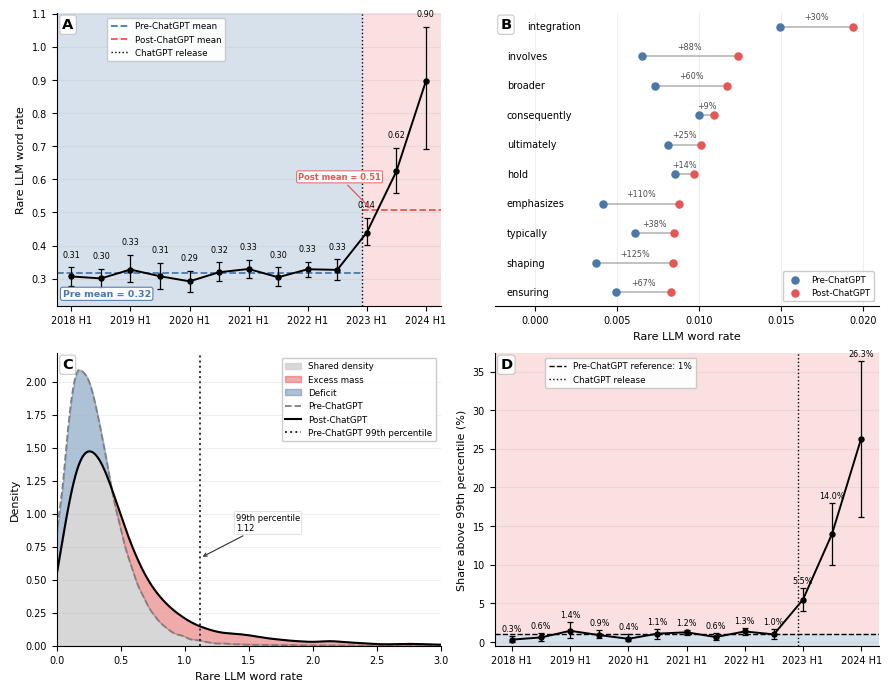

Saved combined Figure 1 to:
  /work/data_assigments/GAI paper/replication/outputs/figures/gai_adoption_figure1.pdf
  /work/data_assigments/GAI paper/replication/outputs/figures/gai_adoption_figure1.png


In [24]:
# ================================================================
# COMBINED FIGURE 1: PNAS NEXUS 2 x 2 MULTIPANEL FIGURE
# ================================================================
#
# Panel A: Rare LLM-associated words over time
# Panel B: Most prevalent individual LLM-associated words after ChatGPT
# Panel C: Pre/post distributional shift
# Panel D: Share above the fixed pre-ChatGPT 99th-percentile threshold
#
# Saves:
#   - vector PDF for submission
#   - 600 dpi PNG
# ================================================================


def add_panel_label(ax, label):
    """Add boxed panel label in upper-left corner."""
    ax.text(
        0.015,
        0.985,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10.5,
        fontweight="bold",
        color="black",
        bbox={
            "boxstyle": "round,pad=0.18",
            "facecolor": "white",
            "edgecolor": "#BFBFBF",
            "linewidth": 0.7,
            "alpha": 0.96,
        },
        zorder=20,
    )


def boxed_legend(
    ax,
    loc="upper right",
    bbox_to_anchor=None,
    **kwargs,
):
    """Consistent readable legend style."""
    return ax.legend(
        loc=loc,
        bbox_to_anchor=bbox_to_anchor,
        frameon=True,
        facecolor="white",
        edgecolor="#C8C8C8",
        framealpha=0.94,
        fancybox=True,
        borderpad=0.45,
        **kwargs,
    )


def sparse_time_ticks(ax, labels, every=2):
    """
    Show fewer time labels and keep them horizontal.
    Always includes the final period.
    """
    positions = list(range(0, len(labels), every))

    if (len(labels) - 1) not in positions:
        positions.append(len(labels) - 1)

    ax.set_xticks(positions)

    ax.set_xticklabels(
        [
            labels.iloc[i] if hasattr(labels, "iloc") else labels[i]
            for i in positions
        ],
        rotation=0,
        ha="center",
    )


with plt.rc_context({
    "font.size": 7.5,
    "axes.labelsize": 8.0,
    "xtick.labelsize": 7.0,
    "ytick.labelsize": 7.0,
    "legend.fontsize": 6.3,
    "axes.linewidth": 0.8,
}):

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(8.8, 6.8),
        layout="constrained",
    )


    ax_a, ax_b = axes[0]
    ax_c, ax_d = axes[1]


    # ============================================================
    # PANEL A
    # RARE LLM-ASSOCIATED WORDS OVER TIME
    # ============================================================

    x_a = np.arange(len(rare_time))

    period_dates_a = pd.to_datetime(
        rare_time["period_start"]
    )

    chatgpt_x_a = np.interp(
        CHATGPT_RELEASE.value,
        period_dates_a.astype("int64"),
        x_a,
    )


    # ------------------------------------------------
    # Before / after shading
    # ------------------------------------------------

    ax_a.axvspan(
        -0.5,
        chatgpt_x_a,
        facecolor=COLORS["before"],
        alpha=0.22,
        zorder=0,
    )

    ax_a.axvspan(
        chatgpt_x_a,
        len(rare_time) - 0.5,
        facecolor=COLORS["after"],
        alpha=0.18,
        zorder=0,
    )


    # ------------------------------------------------
    # Confidence intervals
    # ------------------------------------------------

    yerr_a = np.vstack([
        rare_time["rare_mean"] - rare_time["ci_low"],
        rare_time["ci_high"] - rare_time["rare_mean"],
    ])

    ax_a.errorbar(
        x_a,
        rare_time["rare_mean"],
        yerr=yerr_a,
        fmt="o-",
        color="black",
        ecolor="black",
        linewidth=1.4,
        markersize=3.6,
        elinewidth=0.9,
        capsize=2.2,
        capthick=0.9,
        zorder=3,
    )


    # ------------------------------------------------
    # Point-value annotations
    # ------------------------------------------------

    for position, row in rare_time.reset_index(drop=True).iterrows():
        ax_a.text(
            position,
            row["ci_high"] + 0.025,
            f"{row['rare_mean']:.2f}",
            ha="center",
            va="bottom",
            fontsize=5.8,
            color="black",
            zorder=4,
        )


    # ------------------------------------------------
    # Pooled pre- and post-ChatGPT means
    # ------------------------------------------------

    pre_mean_a = analysis_data.loc[
        analysis_data["after"] == 0,
        "rare_per_100",
    ].mean()

    post_mean_a = analysis_data.loc[
        analysis_data["after"] == 1,
        "rare_per_100",
    ].mean()


    # ------------------------------------------------
    # Horizontal pooled-mean lines
    # ------------------------------------------------

    ax_a.hlines(
        pre_mean_a,
        xmin=-0.5,
        xmax=chatgpt_x_a,
        color=COLORS["before"],
        linestyle="--",
        linewidth=1.3,
        label="Pre-ChatGPT mean",
        zorder=2,
    )

    ax_a.hlines(
        post_mean_a,
        xmin=chatgpt_x_a,
        xmax=len(rare_time) - 0.5,
        color=COLORS["after"],
        linestyle="--",
        linewidth=1.3,
        label="Post-ChatGPT mean",
        zorder=2,
    )


    # ------------------------------------------------
    # Mean annotations (matching standalone logic)
    # ------------------------------------------------

    ax_a.text(
        -0.30,
        pre_mean_a - 0.05,
        f"Pre mean = {pre_mean_a:.2f}",
        color=COLORS["before"],
        ha="left",
        va="top",
        fontsize=6.8,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.22",
            "facecolor": "white",
            "edgecolor": COLORS["before"],
            "linewidth": 0.8,
            "alpha": 0.92,
        },
        zorder=5,
    )

    ax_a.annotate(
        f"Post mean = {post_mean_a:.2f}",
        xy=(chatgpt_x_a + 0.35, post_mean_a),   # point on the post-mean line
        xytext=(chatgpt_x_a - 2.15, post_mean_a + 0.10),  # box position
        color=COLORS["after"],
        ha="left",
        va="center",
        fontsize=6.0,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.18",
            "facecolor": "white",
            "edgecolor": COLORS["after"],
            "linewidth": 0.7,
            "alpha": 0.92,
        },
        arrowprops={
            "arrowstyle": "-",
            "color": COLORS["after"],
            "linewidth": 0.9,
            "shrinkA": 2,
            "shrinkB": 2,
        },
        zorder=5,
    )

    # ------------------------------------------------
    # ChatGPT release marker
    # ------------------------------------------------

    ax_a.axvline(
        chatgpt_x_a,
        color="black",
        linestyle=":",
        linewidth=1.0,
        label="ChatGPT release",
        zorder=2,
    )


    # ------------------------------------------------
    # Sparse horizontal time labels
    # ------------------------------------------------

    sparse_time_ticks(
        ax_a,
        rare_time["period"],
        every=2,
    )

    ax_a.set_xlim(
        -0.5,
        len(rare_time) - 0.5,
    )

    ax_a.set_ylabel(
        "Rare LLM word rate"
    )

    ax_a.set_xlabel("")

    ax_a.grid(
        axis="y",
        alpha=0.20,
    )

    ax_a.spines["top"].set_visible(False)
    ax_a.spines["right"].set_visible(False)

    boxed_legend(
        ax_a,
        loc="upper left",
        bbox_to_anchor=(0.12, 1.0),
        handlelength=1.9,
    )

    add_panel_label(
        ax_a,
        "A",
    )


    # ============================================================
    # PANEL B
    # TOP 10 POST-CHATGPT LLM-ASSOCIATED WORDS
    # ============================================================
    
    plot_data_b = (
        top10_post
        .sort_values(
            "post_rate",
            ascending=True,
        )
        .reset_index(drop=True)
    )
    
    y_b = np.arange(
        len(plot_data_b)
    )
    
    
    # ------------------------------------------------
    # Define plotting range and space for word labels
    # ------------------------------------------------
    
    x_min_b = min(
        plot_data_b["pre_rate"].min(),
        plot_data_b["post_rate"].min(),
    )
    
    x_max_b = max(
        plot_data_b["pre_rate"].max(),
        plot_data_b["post_rate"].max(),
    )
    
    # Add room on the left for labels placed inside the panel
    left_pad_b = 0.32 * x_max_b
    right_pad_b = 0.08 * x_max_b
    
    ax_b.set_xlim(
        x_min_b - left_pad_b,
        x_max_b + right_pad_b,
    )
    
    # Standard x-position for most word labels
    x_text_b = (
        x_min_b
        - 0.88 * left_pad_b
    )
    
    # Move the top word farther right so it clears the B marker
    x_text_top_b = (
        x_min_b - 0.68 * left_pad_b
    )
    
    
    # ------------------------------------------------
    # Dumbbell lines + percentage changes + word labels
    # ------------------------------------------------
    
    for i, row in plot_data_b.iterrows():
    
        x0 = row["pre_rate"]
        x1 = row["post_rate"]
    
        # Dumbbell connector
        ax_b.plot(
            [x0, x1],
            [i, i],
            color="#B0B0B0",
            linewidth=1.1,
            zorder=1,
        )
    
        # Percentage change
        if pd.notnull(x0) and x0 > 0:
    
            pct_change = (
                (x1 - x0)
                / x0
                * 100
            )
    
            label = (
                f"{pct_change:+.0f}%"
            )
    
        else:
    
            label = "new"
    
    
        x_mid = (
            x0 + x1
        ) / 2
    
    
        ax_b.text(
            x_mid,
            i + 0.17,
            label,
            ha="center",
            va="bottom",
            fontsize=5.8,
            color="#4D4D4D",
            zorder=4,
        )
    
    
        # ------------------------------------------------
        # Word labels inside plot
        # ------------------------------------------------
    
        # The highest-ranked word is the final row because
        # plot_data_b is sorted ascending.
        if i == len(plot_data_b) - 1:
    
            word_x = x_text_top_b
    
        else:
    
            word_x = x_text_b
    
    
        ax_b.text(
            word_x,
            i,
            row["word"],
            ha="left",
            va="center",
            fontsize=7.0,
            color="black",
            zorder=4,
        )
    
    
    # ------------------------------------------------
    # Pre / post points
    # ------------------------------------------------
    
    ax_b.scatter(
        plot_data_b["pre_rate"],
        y_b,
        s=26,
        color=COLORS["before"],
        label="Pre-ChatGPT",
        zorder=3,
    )
    
    ax_b.scatter(
        plot_data_b["post_rate"],
        y_b,
        s=26,
        color=COLORS["after"],
        label="Post-ChatGPT",
        zorder=3,
    )
    
    
    # ------------------------------------------------
    # Remove normal external y-axis labels
    # ------------------------------------------------
    
    ax_b.set_yticks(
        y_b
    )
    
    ax_b.set_yticklabels(
        [""] * len(y_b)
    )
    
    ax_b.tick_params(
        axis="y",
        length=0,
    )
    
    
    # ------------------------------------------------
    # Axis labels and styling
    # ------------------------------------------------
    
    ax_b.set_xlabel(
        "Rare LLM word rate"
    )
    
    ax_b.set_ylabel("")
    
    ax_b.grid(
        axis="x",
        alpha=0.20,
    )
    
    ax_b.spines["top"].set_visible(False)
    ax_b.spines["right"].set_visible(False)
    ax_b.spines["left"].set_visible(False)
    
    
    # ------------------------------------------------
    # Legend
    # ------------------------------------------------
    
    boxed_legend(
        ax_b,
        loc="lower right",
    )
    
    
    # ------------------------------------------------
    # Panel label
    # ------------------------------------------------
    
    add_panel_label(
        ax_b,
        "B",
    )


    # ============================================================
    # PANEL C
    # KDE DISTRIBUTIONAL SHIFT
    # ============================================================

    ax_c.fill_between(
        x_grid,
        0,
        shared_density,
        color="lightgray",
        alpha=0.9,
        label="Shared density",
    )

    ax_c.fill_between(
        x_grid,
        pre_density,
        post_density,
        where=(post_density > pre_density),
        interpolate=True,
        color=COLORS["after"],
        alpha=0.50,
        label="Excess mass",
    )

    ax_c.fill_between(
        x_grid,
        post_density,
        pre_density,
        where=(pre_density > post_density),
        interpolate=True,
        color=COLORS["before"],
        alpha=0.45,
        label="Deficit",
    )

    ax_c.plot(
        x_grid,
        pre_density,
        color="gray",
        linestyle="--",
        linewidth=1.3,
        label="Pre-ChatGPT",
    )

    ax_c.plot(
        x_grid,
        post_density,
        color="black",
        linewidth=1.5,
        label="Post-ChatGPT",
    )

    ax_c.axvline(
        PRE_P99,
        color=COLORS["threshold"],
        linestyle=":",
        linewidth=1.4,
        label="Pre-ChatGPT 99th percentile",
    )

    ymax_c = max(
        np.max(pre_density),
        np.max(post_density),
    ) * 1.06

    ax_c.annotate(
        f"99th percentile\n{PRE_P99:.2f}",
        xy=(PRE_P99, ymax_c * 0.30),
        xytext=(PRE_P99 + 0.28, ymax_c * 0.42),
        arrowprops={
            "arrowstyle": "->",
            "linewidth": 0.8,
            "color": COLORS["threshold"],
        },
        ha="left",
        va="center",
        fontsize=6.0,
        bbox={
            "boxstyle": "round,pad=0.2",
            "facecolor": "white",
            "edgecolor": "#D0D0D0",
            "linewidth": 0.5,
            "alpha": 0.90,
        },
    )

    ax_c.set_xlabel(
        "Rare LLM word rate"
    )

    ax_c.set_ylabel(
        "Density"
    )

    ax_c.set_xlim(
        0,
        3,
    )

    ax_c.set_ylim(
        0,
        ymax_c,
    )

    boxed_legend(
        ax_c,
        loc="upper right",
        handlelength=1.8,
    )

    ax_c.spines["top"].set_visible(False)
    ax_c.spines["right"].set_visible(False)

    ax_c.grid(
        axis="y",
        alpha=0.18,
    )

    add_panel_label(
        ax_c,
        "C",
    )


    # ============================================================
    # PANEL D
    # SHARE ABOVE PRE-CHATGPT 99TH PERCENTILE
    # ============================================================

    x_d = np.arange(len(uptake_table))

    y_d = uptake_table["Uptake_percent"].to_numpy()
    ci_low_d = uptake_table["ci_low_percent"].to_numpy()
    ci_high_d = uptake_table["ci_high_percent"].to_numpy()

    baseline_d = 1.0

    yerr_d = np.vstack([
        y_d - ci_low_d,
        ci_high_d - y_d,
    ])

    ax_d.errorbar(
        x_d,
        y_d,
        yerr=yerr_d,
        fmt="o-",
        color="black",
        ecolor="black",
        linewidth=1.4,
        markersize=3.6,
        elinewidth=0.9,
        capsize=2.2,
        capthick=0.9,
        zorder=3,
    )

    ymin_d = min(
        0,
        np.min(ci_low_d) - 0.5,
    )

    ymax_d = max(
        np.max(ci_high_d) + 1.0,
        np.max(y_d) + 1.0,
    )

    ax_d.set_ylim(
        ymin_d,
        ymax_d,
    )

    ax_d.axhspan(
        ymin_d,
        baseline_d,
        facecolor=COLORS["before"],
        alpha=0.22,
        zorder=0,
    )

    ax_d.axhspan(
        baseline_d,
        ymax_d,
        facecolor=COLORS["after"],
        alpha=0.18,
        zorder=0,
    )

    ax_d.axhline(
        baseline_d,
        color="black",
        linestyle="--",
        linewidth=1.0,
        label="Pre-ChatGPT reference: 1%",
        zorder=2,
    )

    period_dates_d = pd.to_datetime(
        uptake_table["period_start"]
    )

    chatgpt_x_d = np.interp(
        CHATGPT_RELEASE.value,
        period_dates_d.astype("int64"),
        x_d,
    )

    ax_d.axvline(
        chatgpt_x_d,
        color="black",
        linestyle=":",
        linewidth=1.0,
        label="ChatGPT release",
        zorder=2,
    )

    sparse_time_ticks(
        ax_d,
        uptake_table["period"],
        every=2,
    )

    ax_d.set_ylabel(
        "Share above 99th percentile (%)"
    )

    ax_d.set_xlabel("")

    for position, row in uptake_table.reset_index(drop=True).iterrows():
        ax_d.text(
            position,
            row["ci_high_percent"] + 0.35,
            f"{row['Uptake_percent']:.1f}%",
            ha="center",
            va="bottom",
            fontsize=5.8,
            color="black",
            zorder=4,
        )

    ax_d.grid(
        axis="y",
        alpha=0.20,
    )

    ax_d.spines["top"].set_visible(False)
    ax_d.spines["right"].set_visible(False)

    boxed_legend(
        ax_d,
        loc="upper left",
        bbox_to_anchor=(0.12, 1.0),
        handlelength=2.0,
    )

    add_panel_label(
        ax_d,
        "D",
    )


    # ============================================================
    # SAVE COMBINED FIGURE
    # ============================================================

    combined_pdf = (
        PLOT_PATH
        / "gai_adoption_figure1.pdf"
    )

    combined_png = (
        PLOT_PATH
        / "gai_adoption_figure1.png"
    )

    fig.savefig(
        combined_pdf,
        bbox_inches="tight",
    )

    fig.savefig(
        combined_png,
        dpi=600,
        bbox_inches="tight",
    )

    plt.show()

    print(
        f"Saved combined Figure 1 to:\n"
        f"  {combined_pdf}\n"
        f"  {combined_png}"
    )